# Conclusion : 
At the begining, our Data contains 03 variables : 
- Filename ; 
- FaceOcclusion (Target) ;  
- Gender.

We have processed Data to generate 18 another Features from image caracteristics at Filename. 
Gender is not a binary variable. It is the probability to be Female (0) or Male (1)  

We need to explore the characteristics of the Target and its relationship between Features.  

# Packages

In [ ]:
import pandas as pd         # For handling CSV and data tables
import numpy as np          # For numeric operations
import matplotlib.pyplot as plt  # For showing images
import cv2                  # For reading and processing images
from PIL import Image       # Another way to open images
import os                   # For working with file paths
import pickle               # For saving/loading Python objects

In [7]:
from functions import show_images, get_device, preprocess_df

# Load Data

In [8]:
df_train = pd.read_csv("Data/listes_training/data_100K/train_100K.csv", delimiter=' ')
df_test = pd.read_csv("Data/listes_training/data_100K/test_students.csv", delimiter=' ')

image_dir = "Data/crops_100K"
device = get_device()

In [9]:
print(df_train.shape)
print(df_test.shape)

(101345, 3)
(30507, 1)


In [10]:
print(df_train.head(-10))
print(type(df_train))

                                                 filename  FaceOcclusion  \
0                               database1/img00011271.jpg          0.019   
1                               database1/img00012471.jpg          0.035   
2                               database1/img00008127.jpg          0.127   
3                               database1/img00008972.jpg          0.014   
4                               database1/img00028187.jpg          0.346   
...                                                   ...            ...   
101330  database3/database3/m.01drbr/59-FaceId-0_align...          0.000   
101331  database3/database3/m.01drbr/69-FaceId-0_align...          0.021   
101332  database3/database3/m.01drbr/7-FaceId-0_align.jpg          0.008   
101333  database3/database3/m.01drbr/71-FaceId-0_align...          0.005   
101334  database3/database3/m.01drbr/72-FaceId-0_align...          0.009   

        gender  
0        0.999  
1        1.000  
2        0.001  
3        0.999  
4 

# Comments : 
Clearly, we will be dealing with images here. For each image, we have the following information:
- Filename which show us the name of image. It will be very usefull to generate another features to help us with the prediction.
- FaceOcclusion, expressed as a percentage ; 
- Gender, which ranges from 0 to 1.

The FaceOcclusion variable is quite straightforward to interpret. For example, 1.9% of the first image is occluded. However, the gender variable is less intuitive. Let's describe it a bit more to better understand what it represents.

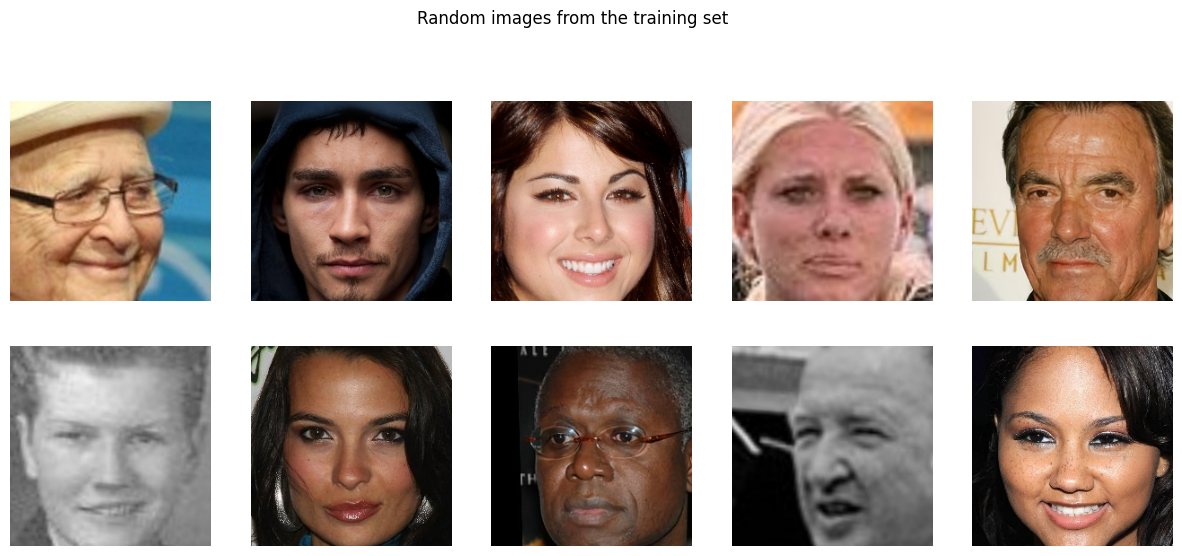

In [14]:
show_images(df_train.sample(10), image_dir, title='Random images from the training set')

As we can see, there are Men and Women in our data. But what can be the Gender frontier when we use the gender variable? 

In [16]:
df_train["gender"].describe()

count    101345.000000
mean          0.599754
std           0.486106
min           0.000000
25%           0.001000
50%           0.996000
75%           0.999000
max           1.000000
Name: gender, dtype: float64

Since the gender value ranges from "0" to "1", it can be interpreted as a probability of being female or male. Can we precise then? 

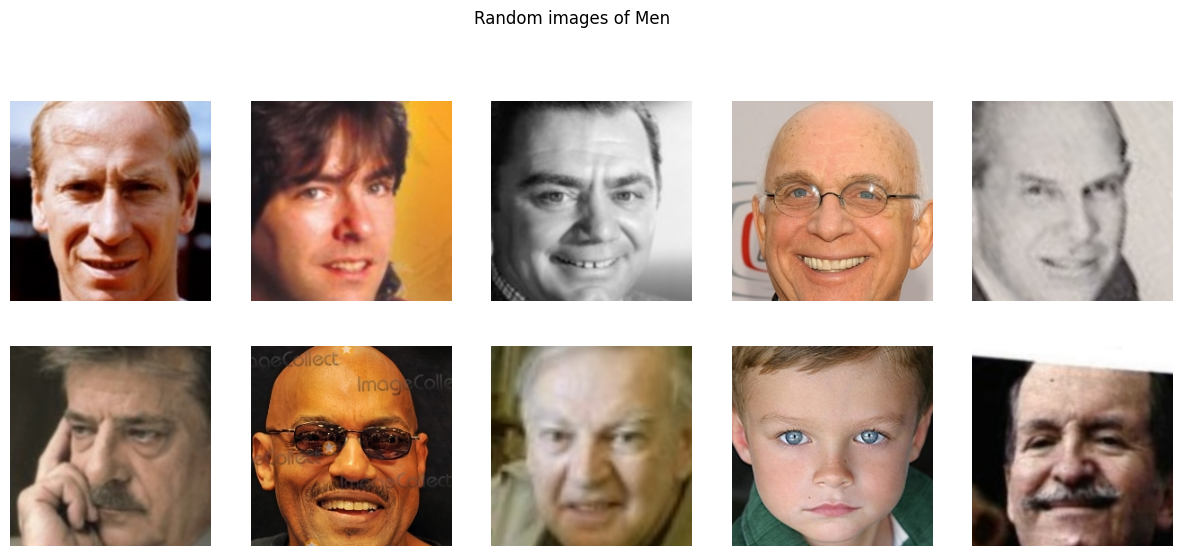

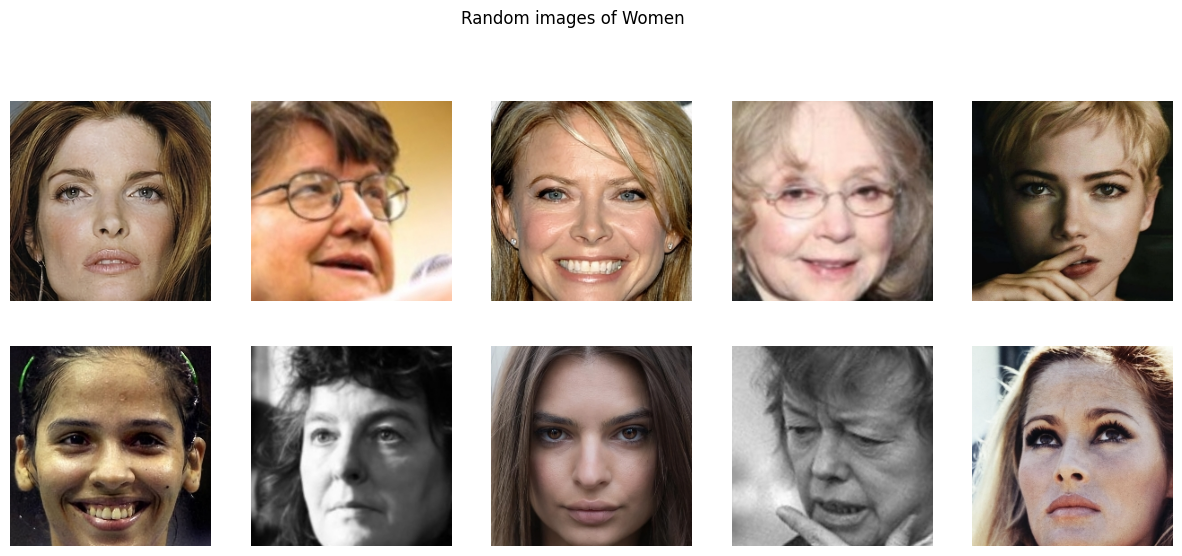

In [25]:
# Let's try 
men = df_train[df_train['gender']>0.5]
women = df_train[df_train['gender']<0.5]

show_images(men.sample(10), image_dir, title='Random images of Men')
show_images(women.sample(10), image_dir, title='Random images of Women')

"0" represents being male and "1" represents being female.  The closer the value is to 0, the more likely the person is male, and vice versa.
50% of the values are below 0.99. It suggests that there might be significantly more females than males in the dataset.

As we can see, some images are in color while others are in black and white. Therefore, we need to create a variable to label each image accordingly. Additionally, we prefer to process images using the RGB (Red, Green, Blue) color model and extract relevant pixel-based variables.

# Processing

## Columns Added during Preprocessing (`preprocess_df`)

The table below describes the new columns automatically generated when image preprocessing is applied to the DataFrame.

| **Column**             | **Description**                                                                 |
|------------------------|----------------------------------------------------------------------------------|
| `initial_index`        | Original row index before preprocessing (helps trace back original rows)         |
| `db_number`            | Database number extracted from `filename` (e.g., `database1/` → `1`)     
We have three Database.       |
| `count`                | Always equal to `1`, useful for aggregation operations (`groupby`)              |
| `color`, `no_color`    | Indicates if the image is in color (`1`) or grayscale (`0`)                     |
| `image_width`          | Width of the image in pixels                                                    |
| `image_height`         | Height of the image in pixels                                                   |
| `pixels`               | Total number of pixels (`width × height`)                                       |
| `pixels_mean`          | Mean of all pixel values (across all channels)                                  |
| `pixels_mean_R/G/B`    | Mean pixel intensity per channel: Red (`R`), Green (`G`), Blue (`B
Why only Red, Green, and Blue (RGB)? Most images are stored in RGB format, where each pixel has 3 color values: R (Red), G (Green), B (Blue). Standard for JPEG, PNG, etc.`)            |
| `pixels_std`           | Standard deviation of all pixel values (overall intensity variation)            |
| `pixels_std_R/G/B`     | Standard deviation per channel (`R`, `G`, `B`)l (`R`, `G`, `B`)

In [35]:
# Preprocessing (circa 10 minutes with GPU)
preprocess = True # False

if preprocess== True:

    # Preprocess the train data
    print('Preprocessing train dataset')
    df_train = preprocess_df(df_train, image_dir, process_mediapipe=False)

    # Preprocess the test data
    print('\nPreprocessing test dataset')
    df_test = preprocess_df(df_test, image_dir, process_mediapipe=False)

    # Save the preprocessed data to pickle file
    with open('pickle/df_train.pkl', 'wb') as file: pickle.dump(df_train, file)
    with open('pickle/df_test.pkl', 'wb') as file:  pickle.dump(df_test, file)

else:
    # opened already preprocessed files
    with open('pickle/df_train.pkl', 'rb') as file:
        df_train = pickle.load(file)
    with open('pickle/df_test.pkl', 'rb') as file:
        df_test = pickle.load(file)

Preprocessing train dataset
0


D:\Télécom_Paris\Data challenge 2.0\functions.py:113: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '107.7478409332483' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'pixels_mean'] = np.mean(image)
D:\Télécom_Paris\Data challenge 2.0\functions.py:114: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '132.7415098852041' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'pixels_mean_R'] = np.mean(image[:, :, 0])
D:\Télécom_Paris\Data challenge 2.0\functions.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '100.51054288903062' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'pixels_mean_G'] = np

5000
10000
15000
20000
25000
30000
35000
40000
45000
50000
55000
60000
65000
70000
75000
80000
85000
90000
95000
100000

Preprocessing test dataset
0


D:\Télécom_Paris\Data challenge 2.0\functions.py:113: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '117.48270753613946' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'pixels_mean'] = np.mean(image)
D:\Télécom_Paris\Data challenge 2.0\functions.py:114: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '137.7704081632653' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'pixels_mean_R'] = np.mean(image[:, :, 0])
D:\Télécom_Paris\Data challenge 2.0\functions.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '104.31028778698979' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'pixels_mean_G'] = n

5000
10000
15000
20000
25000
30000


In [11]:
# Dataset after processing
df_train.head()

,filename,FaceOcclusion,gender,initial_index,gender_id,db_number,count,color,image_width,image_height,...,pixels,pixels_mean,pixels_mean_R,pixels_mean_G,pixels_mean_B,pixels_std,pixels_std_R,pixels_std_G,pixels_std_B,no_color
0,database1/img00011271.jpg,0.019,0.999,0,1,1,1,1,224,224,...,50176,107.747841,132.741510,100.510543,89.991470,83.995129,97.447624,77.424065,68.430032,0
1,database1/img00012471.jpg,0.035,1.000,1,1,1,1,1,224,224,...,50176,115.520176,139.051359,108.359833,99.149334,80.532139,71.841309,79.931149,83.863713,0
2,database1/img00008127.jpg,0.127,0.001,2,0,1,1,1,224,224,...,50176,84.115474,111.611527,81.445791,59.289102,64.644461,73.642430,59.164140,47.261054,0
3,database1/img00008972.jpg,0.014,0.999,3,1,1,1,1,224,224,...,50176,109.190350,134.624302,100.536432,92.410316,48.588847,55.539281,43.584276,33.092015,0
4,database1/img00028187.jpg,0.346,0.982,4,1,1,1,1,224,224,...,50176,100.399567,139.272939,94.241988,67.683773,71.354654,75.586511,61.849424,55.824814,0


In [12]:
df_test.head()

,filename,gender,FaceOcclusion,initial_index,gender_id,db_number,count,color,image_width,image_height,...,pixels,pixels_mean,pixels_mean_R,pixels_mean_G,pixels_mean_B,pixels_std,pixels_std_R,pixels_std_G,pixels_std_B,no_color
0,database2/database2/test/0.jpg,-1.0,-1.0,0,-1,2,1,1,224,224,...,50176,117.482708,137.770408,104.310288,110.367427,84.615352,95.051938,74.508825,79.101876,0
1,database2/database2/test/1.jpg,-1.0,-1.0,1,-1,2,1,1,224,224,...,50176,93.076458,103.743603,91.258410,84.227360,83.481748,91.830888,80.793327,75.840182,0
2,database2/database2/test/2.jpg,-1.0,-1.0,2,-1,2,1,0,224,224,...,50176,157.171098,157.171098,157.171098,157.171098,87.781607,87.781607,87.781607,87.781607,1
3,database2/database2/test/3.jpg,-1.0,-1.0,3,-1,2,1,1,224,224,...,50176,67.997821,117.794105,62.462153,23.737205,77.965464,90.714246,62.294459,40.704438,0
4,database2/database2/test/4.jpg,-1.0,-1.0,4,-1,2,1,1,224,224,...,50176,82.819622,87.928711,74.618901,85.911252,63.861377,72.996544,57.568811,59.069875,0


## Export Data

In [ ]:
## Export Data
df_train.to_csv("df_train.csv", index_label = False)
df_test.to_csv("df_test.csv", index_label = False)